In [1]:
# Step 1: Load data and do basic cleaning

import pandas as pd
import numpy as np


In [2]:
# Load the dataset from CSV file
df = pd.read_csv('diabetes.csv')


In [4]:
# Replace '?' values with NaN (missing values)
df.replace('?', np.nan, inplace=True)

# Drop unnecessary columns that are not useful for analysis/model
df.drop(columns=[
    'weight', 
    'payer_code', 
    'medical_specialty', 
    'id', 
    'encounter_id', 
    'patient_nbr'
], inplace=True)

# Handle missing values (fill them)
# Loop through each column
for col in df.columns:
    
    # Check if the column has missing values
    if df[col].isnull().sum() > 0:
        
        # Fill missing values with the most frequent value (mode)
        df[col].fillna(df[col].mode()[0], inplace=True)

# Print a confirmation message
print("Data successfully loaded and cleaned. Ready for visualization!")

C:\Users\User\AppData\Local\Temp\ipykernel_15844\1368807932.py:22: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].mode()[0], inplace=True)


Data successfully loaded and cleaned. Ready for visualization!


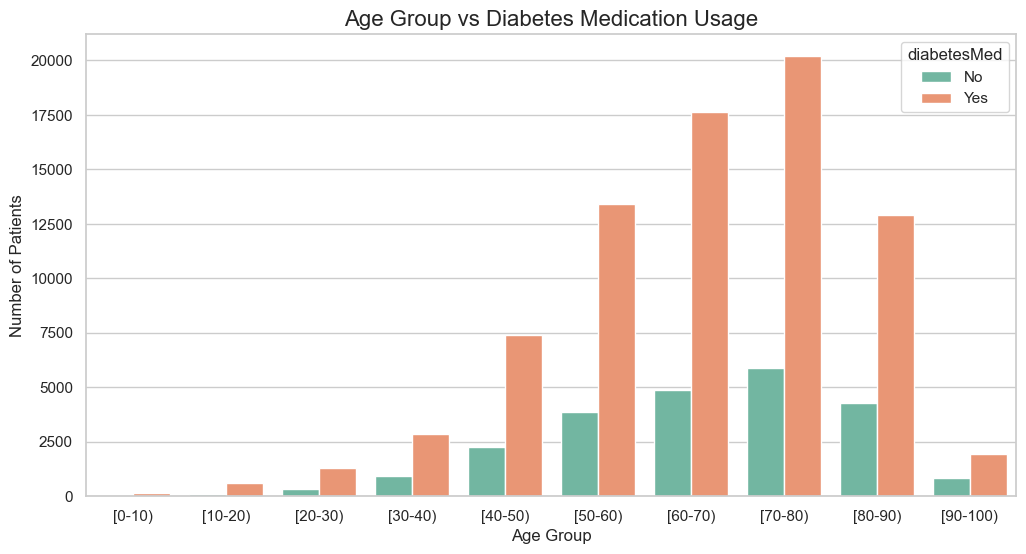

In [6]:
# Step 2: Create a bar chart to compare Age groups and Diabetes medication usage

import matplotlib.pyplot as plt
import seaborn as sns

# Set a clean and modern style for the plots
sns.set_theme(style="whitegrid")

# Set figure size (width, height)
plt.figure(figsize=(12, 6))

# Create a count plot:
# x-axis → Age groups
# hue → Whether the patient uses diabetes medication or not
sns.countplot(x='age', hue='diabetesMed', data=df, palette='Set2')

# Add title and labels
plt.title('Age Group vs Diabetes Medication Usage', fontsize=16)
plt.xlabel('Age Group', fontsize=12)
plt.ylabel('Number of Patients', fontsize=12)

# Display the chart
plt.show()

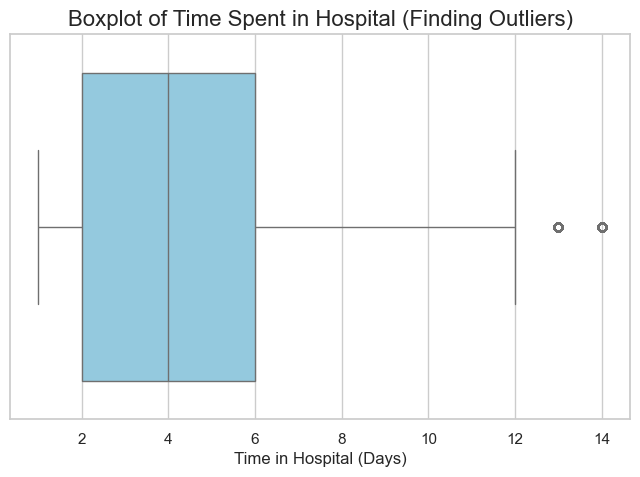

In [7]:
# Step 3: Create a boxplot for 'time_in_hospital' to detect outliers
plt.figure(figsize=(8, 5))

sns.boxplot(x=df['time_in_hospital'], color='skyblue')

plt.title('Boxplot of Time Spent in Hospital (Finding Outliers)', fontsize=16)
plt.xlabel('Time in Hospital (Days)', fontsize=12)
plt.show()

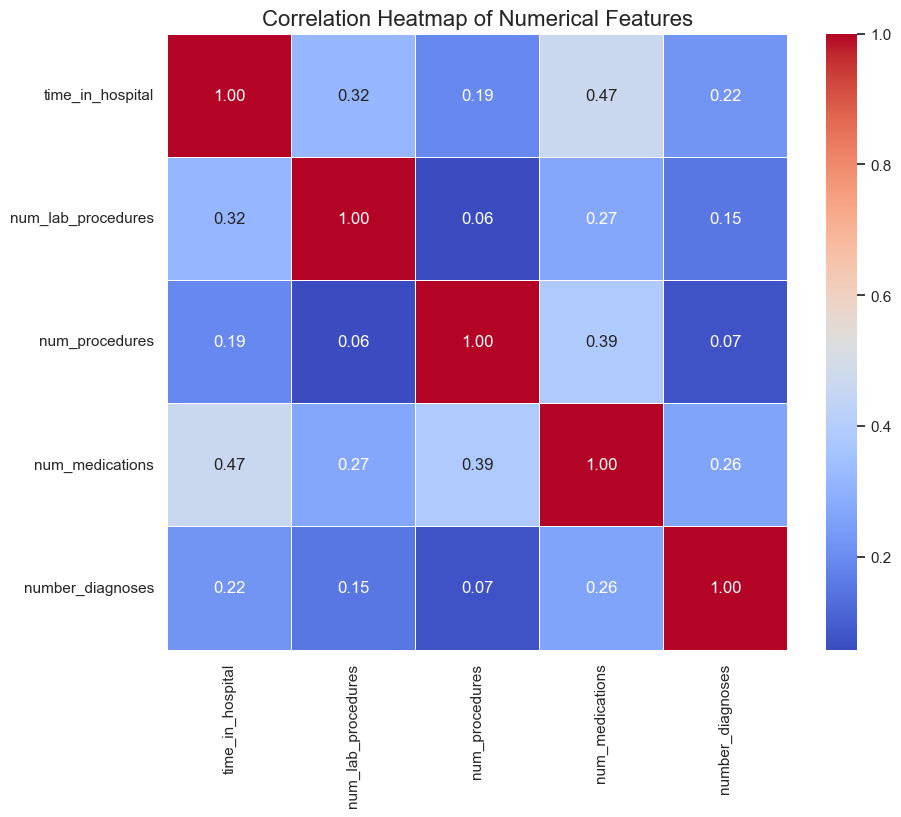

In [8]:
# Step 4: Create a correlation heatmap for selected numerical features

# Select only important numerical columns
num_cols = [
    'time_in_hospital', 
    'num_lab_procedures', 
    'num_procedures', 
    'num_medications', 
    'number_diagnoses'
]

# Set figure size
plt.figure(figsize=(10, 8))

# Create heatmap:
# .corr() → calculates correlation between columns
# annot=True → shows correlation values inside the boxes
# cmap → color style (blue = low, red = high correlation)
sns.heatmap(
    df[num_cols].corr(), 
    annot=True, 
    cmap='coolwarm', 
    fmt=".2f", 
    linewidths=0.5
)

# Add title
plt.title('Correlation Heatmap of Numerical Features', fontsize=16)

# Display the heatmap
plt.show()

In [9]:
# Step 5: Convert text (categorical) columns into numbers for the algorithm
from sklearn.preprocessing import LabelEncoder

# Initialize the label encoder
le = LabelEncoder()

# Loop through all columns
for col in df.columns:
    
    # Check if column is of object type (categorical/text)
    if df[col].dtype == 'object':
        
        # Convert categories into numeric labels
        df[col] = le.fit_transform(df[col])

# Print confirmation message
print("Data is ready for the Decision Tree algorithm!")

Data is ready for the Decision Tree algorithm!


In [10]:
print(df.head())

   race  gender  age  admission_type_id  discharge_disposition_id  \
0     2       0    0                  6                        25   
1     2       0    1                  1                         1   
2     0       0    2                  1                         1   
3     2       1    3                  1                         1   
4     2       1    4                  1                         1   

   admission_source_id  time_in_hospital  num_lab_procedures  num_procedures  \
0                    1                 1                  41               0   
1                    7                 3                  59               0   
2                    7                 2                  11               5   
3                    7                 2                  44               1   
4                    7                 1                  51               0   

   num_medications  ...  citoglipton  insulin  glyburide.metformin  \
0                1  ...           

In [11]:
# Step 6: Run Decision Tree Classifier

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

# Separate features (X) and target variable (y)
X = df.drop('readmitted', axis=1)  # all columns except target
y = df['readmitted']               # target column

# Split data into 80% training and 20% testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Create the Decision Tree model
# max_depth=10 controls tree size to prevent overfitting
dt_model = DecisionTreeClassifier(random_state=42, max_depth=10)

# Train the model on training data
dt_model.fit(X_train, y_train)

# Make predictions on test data
dt_predictions = dt_model.predict(X_test)

# Calculate accuracy of the model
dt_accuracy = accuracy_score(y_test, dt_predictions)

# Print the accuracy
print(f"Decision Tree Model Accuracy: {dt_accuracy * 100:.2f}%")

Decision Tree Model Accuracy: 57.43%
